# UpSet plots & intersections

In [70]:
import os
import sys
import glob
import warnings
import openpyxl
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the src directory is in the Python path
scripts = os.path.abspath('')
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)

import get_silk_genes as silk
from id_converter import convert_locs_to_hogs, convert_hogs_to_locs

from odds_ratio_test import BootstrapTestResults

# Define paths to data and results directories
data = os.path.join(scripts, "..", "data")
figures = os.path.join(scripts, "..", "figures")
assets = os.path.join(scripts, "..", "assets")
results = os.path.join(scripts, "..", "results")

# Suppress FutureWarnings and SyntaxWarnings from libraries (especially upsetplot)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Read all the hit lists into a dictionary (as HOGs)

In [71]:
hits_lists = {}

### Silk gland genes & spidroins

In [ ]:
silk_genes_list = silk.get_all_silk_genes(top10=False)
spidroins_list = pd.read_csv(f'{assets}/spidroins_LOCs.tsv', sep='\t', dtype=str)['LOC'].tolist()

# There may end up being LOCs in these HOGs that are not in my silk gland gene list
# or spidroin list. However, if they are orthologous to those LOCs, they are still relevant.
silk_hogs = convert_locs_to_hogs(silk_genes_list, f'{assets}/N5.tsv')
spidroin_hogs = convert_locs_to_hogs(spidroins_list, f'{assets}/N5.tsv')

# These lists of HOGs are longer than the original lists of LOCs, meaning some LOCs 
# belong to multiple HOGs. This may be because multiple isoforms of the gene were 
# included in the original Orthofinder analysis.
hits_lists['silk_genes'] = list(set(silk_hogs['HOG'].tolist()))
hits_lists['spidroins'] = list(set(spidroin_hogs['HOG'].tolist()))

### Hyphy results

In [74]:
hyphy_results = results + "/hyphy_results_cache/"

# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(str(hyphy_results + "relax_results.pkl"))
relax_result_fltrd = relax_result.filter_omega(10000)
relax_df_fltrd = relax_result_fltrd.results_df
hits_lists['relaxed'] = list(relax_df_fltrd[relax_df_fltrd['result']=='relaxed'].index)
hits_lists['intensified'] = list(relax_df_fltrd[relax_df_fltrd['result']=='intensified'].index)

# Load the saved BUSTED-PH results
busted_ph_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_results.pkl"))
busted_ph_result_fltrd = busted_ph_result.filter_omega(10000)
busted_ph_df_fltrd = busted_ph_result_fltrd.results_df
hits_lists['busted_ph'] = list(busted_ph_df_fltrd[busted_ph_df_fltrd['result']=='hit'].index)

# Load the saved BUSTED-PH-REV results
busted_ph_rev_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_rev_results.pkl"))


busted_ph_rev_result_fltrd = busted_ph_rev_result.filter_omega(10000)
busted_ph_rev_df_fltrd = busted_ph_rev_result_fltrd.results_df
hits_lists['busted_ph_rev'] = list(busted_ph_rev_df_fltrd[busted_ph_rev_df_fltrd['result']=='hit'].index)

### Odds ratio test results

Using the left-tailed results arbitrarily, since both runs of the test produced lists of significant hogs on both sides. (Left-tailed vs right-tailed refers to whether the overall distributions were significantly different, not whether or not individual HOGs were favored by orb-weavers or non-orbweavers)

In [75]:
ort_50_dir = results + "/odds_ratio_test_50"
ort_75_dir = results + "/odds_ratio_test_75"

# Duplication results
duplication_ort_50 = BootstrapTestResults.load_from_pickle(f'{ort_50_dir}/duplication_occ50-98_LT.pkl')
dup_50_df = duplication_ort_50.results_fltrd_df

duplication_ort_75 = BootstrapTestResults.load_from_pickle(f'{ort_75_dir}/duplication_occ75-98_LT.pkl')
dup_75_df = duplication_ort_75.results_fltrd_df

# Loss results
loss_ort_50 = BootstrapTestResults.load_from_pickle(f'{ort_50_dir}/loss_occ50-95_LT.pkl')
loss_50_df = loss_ort_50.results_fltrd_df

loss_ort_75 = BootstrapTestResults.load_from_pickle(f'{ort_75_dir}/loss_occ75-95_LT.pkl')
loss_75_df = loss_ort_75.results_fltrd_df

Confirming that the 2 runs of each bootstrap test (left-tailed and right-tailed) designated the same set of orthogroups as significant

In [76]:
ort_50_dir = results + "/odds_ratio_test_50"
ort_75_dir = results + "/odds_ratio_test_75"

# Duplication results
duplication_ort_50_r = BootstrapTestResults.load_from_pickle(f'{ort_50_dir}/duplication_occ50-98_RT.pkl')
dup_50_df_r = duplication_ort_50.results_fltrd_df

duplication_ort_75_r = BootstrapTestResults.load_from_pickle(f'{ort_75_dir}/duplication_occ75-98_RT.pkl')
dup_75_df_r = duplication_ort_75.results_fltrd_df

# Loss results
loss_ort_50_r = BootstrapTestResults.load_from_pickle(f'{ort_50_dir}/loss_occ50-95_RT.pkl')
loss_50_df_r = loss_ort_50.results_fltrd_df

loss_ort_75_r = BootstrapTestResults.load_from_pickle(f'{ort_75_dir}/loss_occ75-95_RT.pkl')
loss_75_df_r = loss_ort_75.results_fltrd_df

In [77]:
print(
    dup_50_df.equals(dup_50_df_r),
    dup_75_df.equals(dup_75_df_r),
    loss_50_df.equals(loss_50_df_r),
    loss_75_df.equals(loss_75_df_r),
)

True True True True


But the test results themselves were not identical; they produced different but very similar bootstrapped alpha thresholds.

In [78]:
print(
    loss_ort_50.ci_av,
    loss_ort_50_r.ci_av
)

[-1.38433089  1.38801583] [-1.38416918  1.38244859]


Break down into HOGs that were more likely to be missing or in multiple copies in orbweavers or in non-orbweavers

In [79]:
hits_lists_50 = hits_lists.copy()
hits_lists_75 = hits_lists.copy()

In [80]:
hits_lists_50['dup_50_orb'] = list(dup_50_df[dup_50_df["Log odds ratio"] > 0].index)
hits_lists_50['dup_50_nonorb'] = list(dup_50_df[dup_50_df["Log odds ratio"] < 0].index)
hits_lists_50['loss_50_orb'] = list(loss_50_df[loss_50_df["Log odds ratio"] > 0].index)
hits_lists_50['loss_50_nonorb'] = list(loss_50_df[loss_50_df["Log odds ratio"] < 0].index)

hits_lists_75['dup_75_orb'] = list(dup_75_df[dup_75_df["Log odds ratio"] > 0].index)
hits_lists_75['dup_75_nonorb'] = list(dup_75_df[dup_75_df["Log odds ratio"] < 0].index)
hits_lists_75['loss_75_orb'] = list(loss_75_df[loss_75_df["Log odds ratio"] > 0].index)
hits_lists_75['loss_75_nonorb'] = list(loss_75_df[loss_75_df["Log odds ratio"] < 0].index)

## UpSet plot of Hyphy results only

In [81]:
hyphy_upset_dict = {
    'Selection $\it{relaxed}$ in non-orbweavers': hits_lists['relaxed'],
    'Positive selection ~ orbweaving': hits_lists['busted_ph'],
    'Positive selection ~ $\it{non}$-orbweaving': hits_lists['busted_ph_rev'],
    'Selection $\it{intensified}$ in non-orbweavers': hits_lists['intensified'],
}

upset_data = from_contents(hyphy_upset_dict)

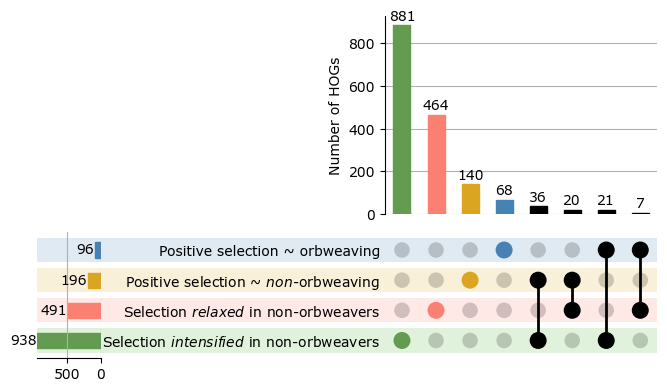

In [82]:
upset = UpSet(
    upset_data, show_counts=True,
)

upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')

upset.style_subsets(present=['Selection $\it{relaxed}$ in non-orbweavers'], 
                    absent=['Positive selection ~ orbweaving', 'Positive selection ~ $\it{non}$-orbweaving', 'Selection $\it{intensified}$ in non-orbweavers'],
                    facecolor='#FA8072')
upset.style_subsets(present=['Positive selection ~ orbweaving'], 
                    absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ $\it{non}$-orbweaving', 
                            'Selection $\it{intensified}$ in non-orbweavers'],
                    facecolor='#4682B4')
upset.style_subsets(present=['Positive selection ~ $\it{non}$-orbweaving'], 
                    absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ orbweaving', 'Selection $\it{intensified}$ in non-orbweavers'],
                    facecolor='#DAA520')
upset.style_subsets(present=['Selection $\it{intensified}$ in non-orbweavers'], 
                    absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ orbweaving', 'Positive selection ~ $\it{non}$-orbweaving'],
                    facecolor='#639B51')

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.savefig(str(figures + '/figure_3/hyphy_upset.png'), dpi=300, transparent=False, bbox_inches='tight')

## UpSet plot of Hyphy results + silk genes/spidroins

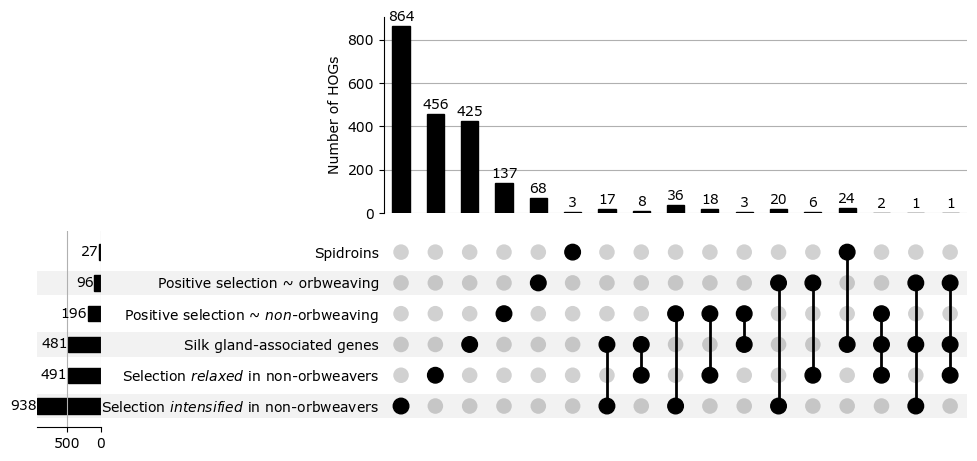

In [83]:
upset_dict_with_silk = hyphy_upset_dict.copy()
upset_dict_with_silk['Silk gland-associated genes'] = hits_lists['silk_genes']
upset_dict_with_silk['Spidroins'] = hits_lists['spidroins']

upset_data_with_silk = from_contents(upset_dict_with_silk)

upset = UpSet(
    upset_data_with_silk, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'


# Odds ratio test upset

Text(0.5, 1.0, 'Odds ratio test (occ > 50)')

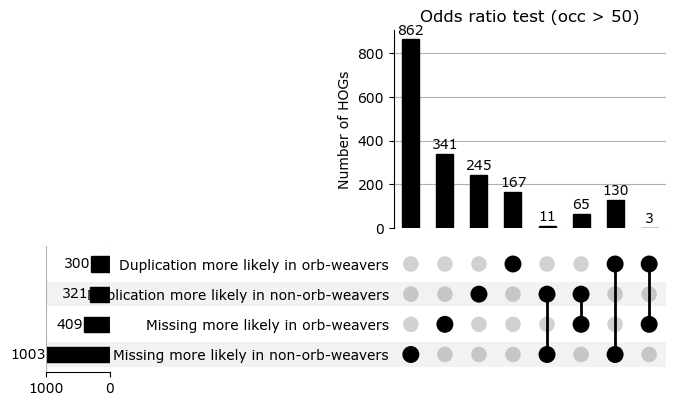

In [84]:
upset_dict_with_ort_50 = {}
upset_dict_with_ort_50['Missing more likely in orb-weavers'] = hits_lists_50['loss_50_orb']
upset_dict_with_ort_50['Missing more likely in non-orb-weavers'] = hits_lists_50['loss_50_nonorb']
upset_dict_with_ort_50['Duplication more likely in orb-weavers'] = hits_lists_50['dup_50_orb']
upset_dict_with_ort_50['Duplication more likely in non-orb-weavers'] = hits_lists_50['dup_50_nonorb']

upset_data_with_ort_50 = from_contents(upset_dict_with_ort_50)

upset = UpSet(
    upset_data_with_ort_50, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.title('Odds ratio test (occ > 50)')


Text(0.5, 1.0, 'Odds ratio test (occ > 75)')

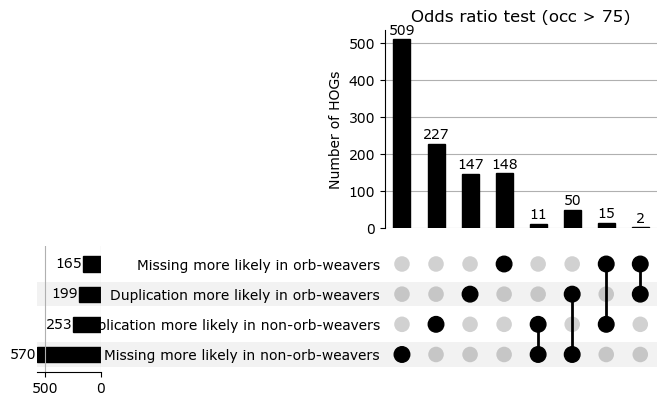

In [85]:
upset_dict_with_ort_75 = {}
upset_dict_with_ort_75['Missing more likely in orb-weavers'] = hits_lists_75['loss_75_orb']
upset_dict_with_ort_75['Missing more likely in non-orb-weavers'] = hits_lists_75['loss_75_nonorb']
upset_dict_with_ort_75['Duplication more likely in orb-weavers'] = hits_lists_75['dup_75_orb']
upset_dict_with_ort_75['Duplication more likely in non-orb-weavers'] = hits_lists_75['dup_75_nonorb']

upset_data_with_ort_75 = from_contents(upset_dict_with_ort_75)

upset = UpSet(
    upset_data_with_ort_75, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.title('Odds ratio test (occ > 75)')


## Odds ratio test upset with silk genes/spidroins

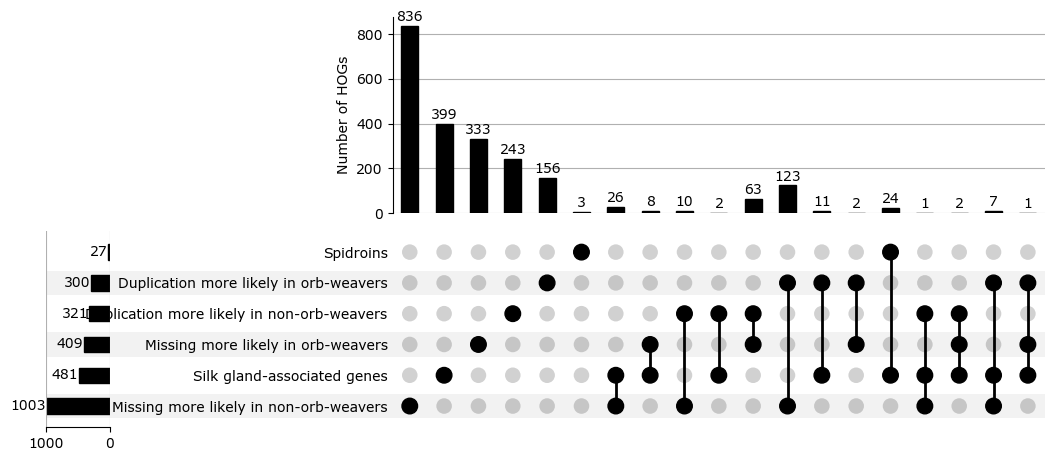

In [86]:
upset_dict_with_silk_ort_50 = upset_dict_with_ort_50.copy()
upset_dict_with_silk_ort_50['Silk gland-associated genes'] = hits_lists['silk_genes']
upset_dict_with_silk_ort_50['Spidroins'] = hits_lists['spidroins']

upset_data_with_silk_ort_50 = from_contents(upset_dict_with_silk_ort_50)

upset = UpSet(
    upset_data_with_silk_ort_50, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'

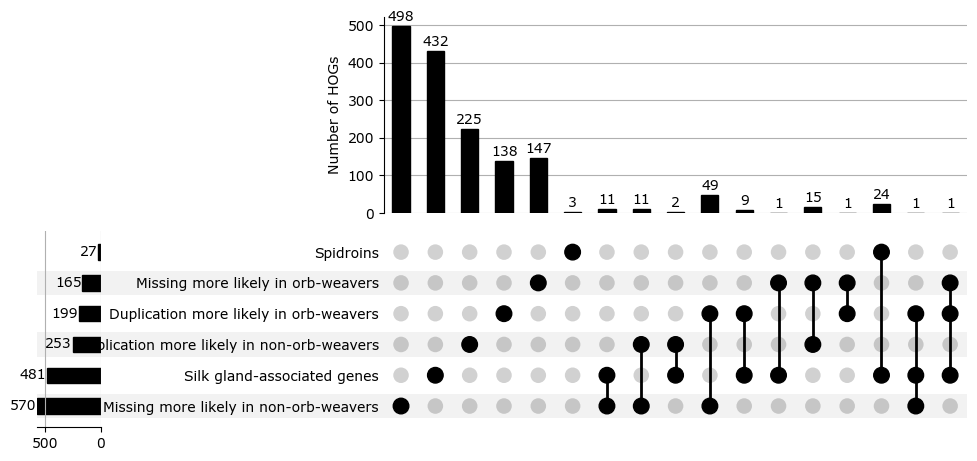

In [87]:
upset_dict_with_silk_ort_75 = upset_dict_with_ort_75.copy()
upset_dict_with_silk_ort_75['Silk gland-associated genes'] = hits_lists['silk_genes']
upset_dict_with_silk_ort_75['Spidroins'] = hits_lists['spidroins']

upset_data_with_silk_ort_75 = from_contents(upset_dict_with_silk_ort_75)

upset = UpSet(
    upset_data_with_silk_ort_75, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'

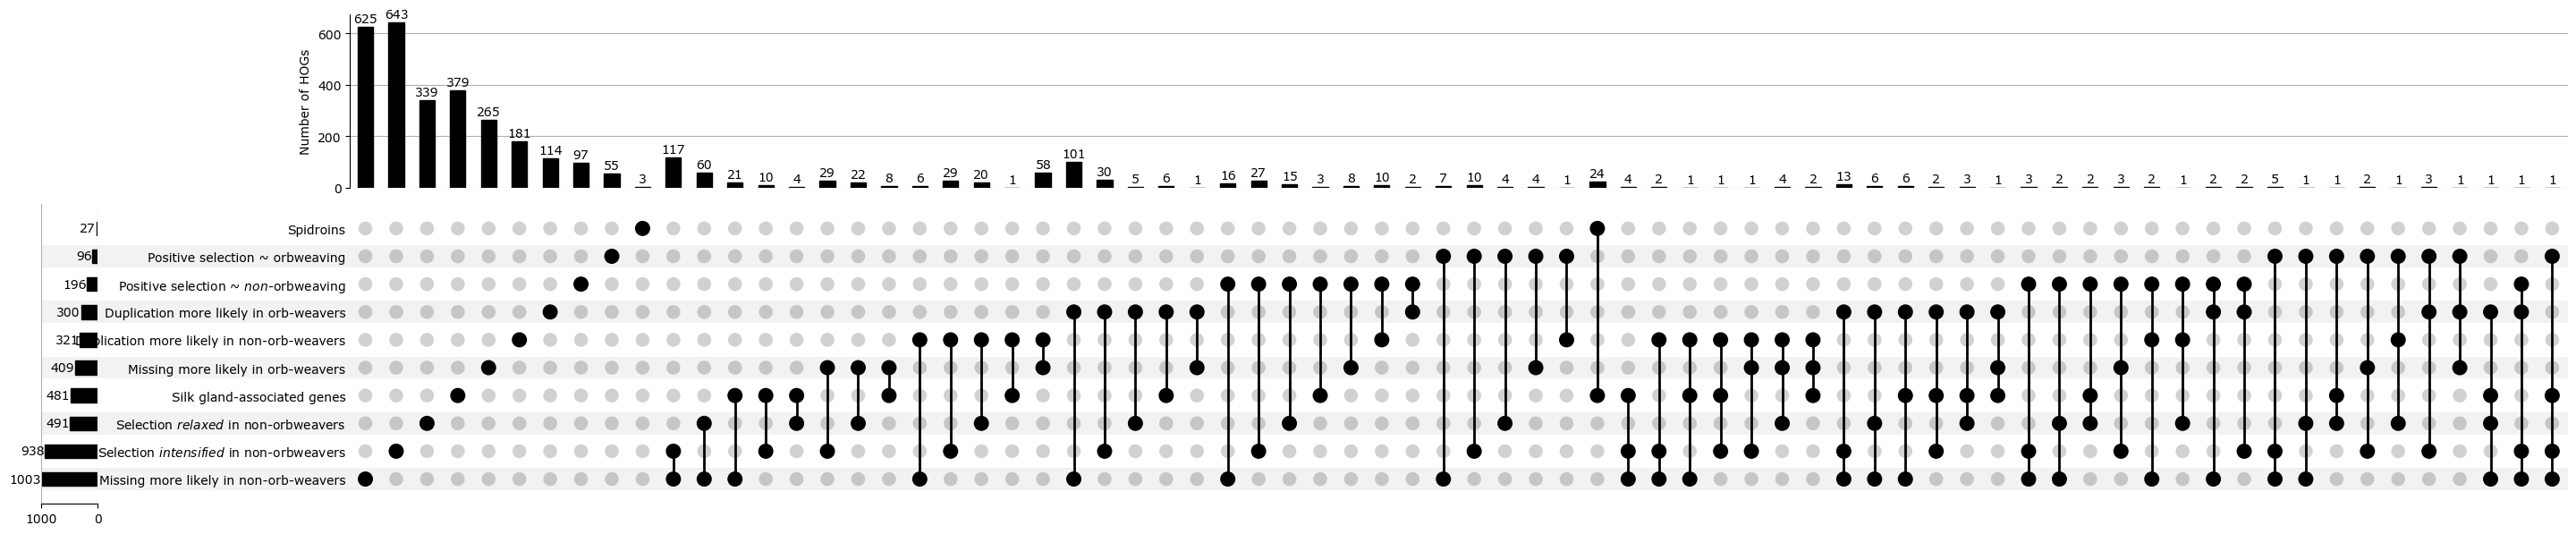

In [88]:
upset_dict_massive_50 = upset_dict_with_silk_ort_50 | hyphy_upset_dict

upset_data_massive = from_contents(upset_dict_massive_50)

upset = UpSet(
    upset_data_massive, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'

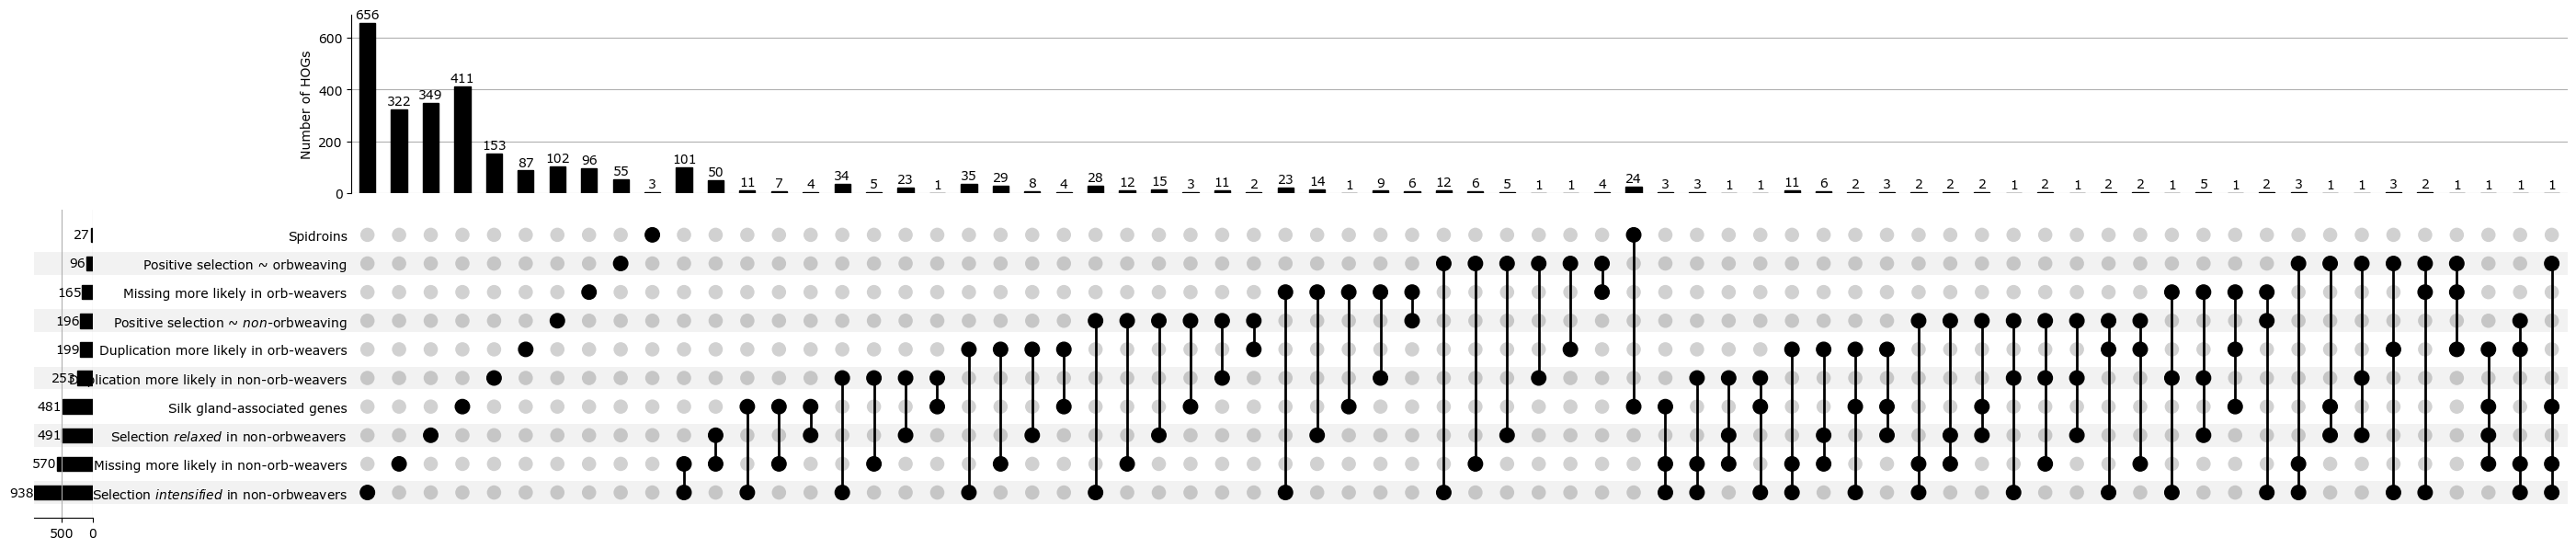

In [97]:
upset_dict_massive_75 = upset_dict_with_silk_ort_75 | hyphy_upset_dict

upset_data_massive = from_contents(upset_dict_massive_75)

upset = UpSet(
    upset_data_massive, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.savefig(str(figures + '/figure_4/massive_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')

In [90]:
def get_intersections(upset_dict, exclude=True):

    import itertools

    # Get all set names
    set_names = list(upset_dict.keys())

    # Convert lists to sets for set operations
    sets = {k: set(v) for k, v in upset_dict.items()}

    intersections = []

    # For all intersections (size 2 and up)
    for r in range(1, len(set_names) + 1):
        for combo in itertools.combinations(set_names, r):
            # Intersection of the selected sets
            intersect = sets[combo[0]].copy()
            for name in combo[1:]:
                intersect &= sets[name]
            if exclude:
                # Exclude elements present in any other set not in the combo (UpSet logic)
                other_sets = set(set_names) - set(combo)
                for name in other_sets:
                    intersect -= sets[name]
            if intersect:
                intersections.append((combo, sorted(intersect)))

    # Sort by decreasing length of intersection
    intersections.sort(key=lambda x: len(x[1]), reverse=True)

    # Remove intersections where the combo contains only one set
    intersections = [item for item in intersections if len(item[0]) > 1]

    # intersections now contains tuples: (combo, [elements]), sorted by size
    intersections_df = pd.DataFrame([
        {"Sets": ", ".join(combo), "Num_HOGs": len(hogs), "HOGs": ", ".join(hogs)}
        for combo, hogs in intersections
    ])

    intersections_df['HOGs'] = intersections_df['HOGs'].apply(lambda x: x.split(", ") if pd.notnull(x) else [])

    return intersections_df

In [91]:
intersections = get_intersections(hits_lists_50)

In [92]:
intersections_expanded = intersections.explode('HOGs').set_index('HOGs', drop=True)[['Sets']]
intersections_expanded

,Sets
HOGs,
N5.HOG0010646,"intensified, loss_50_nonorb"
N5.HOG0011852,"intensified, loss_50_nonorb"
N5.HOG0014835,"intensified, loss_50_nonorb"
N5.HOG0017829,"intensified, loss_50_nonorb"
N5.HOG0020603,"intensified, loss_50_nonorb"
...,...
N5.HOG0041065,"intensified, dup_50_nonorb, loss_50_orb"
N5.HOG0017104,"busted_ph, dup_50_orb, loss_50_orb"
N5.HOG0005597,"silk_genes, relaxed, dup_50_orb, loss_50_nonorb"


In [93]:
intersections_locs = convert_hogs_to_locs(intersections_expanded, f'{assets}/N5.tsv')

Processing HOGs: 100%|██████████| 739/739 [00:00<00:00, 1194.01it/s]


In [ ]:
intersections_list_fltrd = intersections_locs[['HOGs', 'Sets', 'LOC', 'GO_terms', 'Description']].drop_duplicates().reset_index(drop=True)
intersections_list_fltrd.to_excel(f'{results}/intersections.xlsx', index=False)